# Google Merchandise Store Funnel Analysis

## Python Exploratory Data Analysis


### Import Libraries and Load Datasets

In [4]:

import pandas as pd
import matplotlib.pyplot as plt

events = pd.read_csv( "events_clean.csv")
items = pd.read_csv("items.csv")
users = pd.read_csv( "users.csv")

print("Events:", events.shape)
print("Items:", items.shape)
print("Users:", users.shape)

Events: (719386, 7)
Items: (1381, 6)
Users: (270154, 3)


### Dataset Overview and Initial Inspection


In [43]:
events.head()

,user_id,ga_session_id,country,device,type,item_id,date
0,2133,16909,US,mobile,purchase,94,01-11-2020 00:27
1,2133,16909,US,mobile,purchase,425,01-11-2020 00:27
2,5789,16908,SE,desktop,purchase,1,01-11-2020 01:44
3,5789,16908,SE,desktop,purchase,62,01-11-2020 01:44
4,5808,4267,US,mobile,add_to_cart,842,01-11-2020 03:06


In [44]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 719386 entries, 0 to 719385
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user_id        719386 non-null  int64
 1   ga_session_id  719386 non-null  int64
 2   country        719386 non-null  str  
 3   device         719386 non-null  str  
 4   type           719386 non-null  str  
 5   item_id        719386 non-null  int64
 6   date           719386 non-null  str  
dtypes: int64(3), str(4)
memory usage: 62.9 MB


In [20]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            1381 non-null   int64
 1   name          1381 non-null   str  
 2   brand         1381 non-null   str  
 3   variant       973 non-null    str  
 4   category      1381 non-null   str  
 5   price_in_usd  1381 non-null   int64
dtypes: int64(2), str(4)
memory usage: 130.6 KB


In [21]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 270154 entries, 0 to 270153
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   id      270154 non-null  int64
 1   ltv     270154 non-null  int64
 2   date    270154 non-null  str  
dtypes: int64(2), str(1)
memory usage: 11.1 MB


In [22]:
items.describe()

,id,price_in_usd
count,1381.000000,1381.000000
mean,690.000000,26.322954
std,398.804672,23.283663
min,0.000000,1.000000
25%,345.000000,13.000000
50%,690.000000,20.000000
75%,1035.000000,32.000000
max,1380.000000,313.000000


In [17]:
users.describe()

,id,ltv
count,270154.000000,270154.000000
mean,135076.500000,1.508865
std,77986.886649,19.768717
min,0.000000,0.000000
25%,67538.250000,0.000000
50%,135076.500000,0.000000
75%,202614.750000,0.000000
max,270153.000000,3360.000000


## 1. Funnel Performance

How does event volume change from add to cart to checkout and purchase?


### Funnel-Stage Event Counts

In [5]:
funnel_stages = [
    "add_to_cart",
    "begin_checkout",
    "purchase"
]

funnel_data = (
    events["type"]
    .value_counts()
    .reindex(funnel_stages, fill_value=0)
)

add_to_cart_events = funnel_data["add_to_cart"]
checkout_events = funnel_data["begin_checkout"]
purchase_events = funnel_data["purchase"]

cart_to_checkout_rate = (
    checkout_events / add_to_cart_events * 100
)

checkout_to_purchase_rate = (
    purchase_events / checkout_events * 100
)

overall_conversion_rate = (
    purchase_events / add_to_cart_events * 100
)

funnel_kpis = pd.DataFrame({
    "KPI": [
        "Cart-to-Checkout Rate",
        "Checkout-to-Purchase Rate",
        "Purchase-to-Cart Rate"
    ],
    "Value (%)": [
        cart_to_checkout_rate,
        checkout_to_purchase_rate,
        overall_conversion_rate
    ]
})

display(funnel_data.to_frame("Events"))
display(funnel_kpis.round(2))

,Events
type,
add_to_cart,666071
begin_checkout,38604
purchase,14711


,KPI,Value (%)
0,Cart-to-Checkout Rate,5.80
1,Checkout-to-Purchase Rate,38.11
2,Purchase-to-Cart Rate,2.21


### Funnel Performance chart

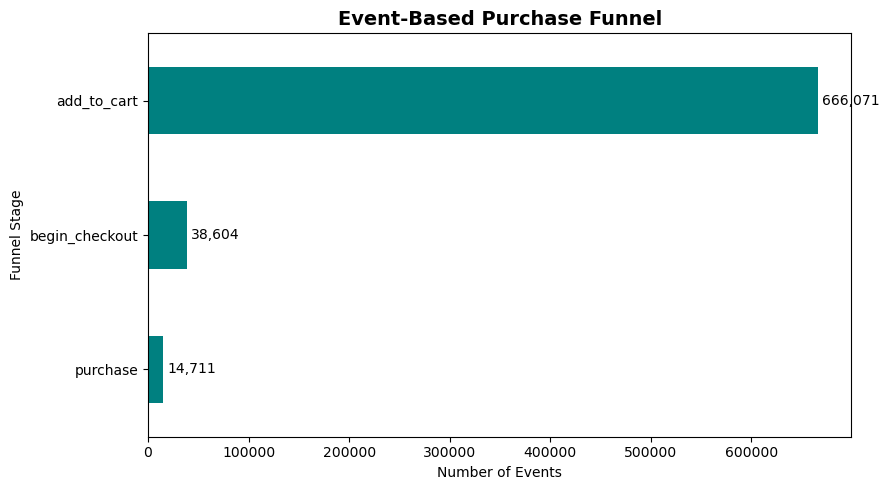

In [12]:
funnel_visual = funnel_data.iloc[::-1]

ax = funnel_visual.plot(
    kind="barh",
    figsize=(9, 5),
    color="Teal"
)

ax.set_title(
    "Event-Based Purchase Funnel",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Number of Events")
ax.set_ylabel("Funnel Stage")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:,.0f}" for value in funnel_visual],
        padding=3
    )

plt.tight_layout()
plt.show()

### Funnel Insight

Event volume falls sharply before checkout. Begin-checkout events equal only **5.80%** of add-to-cart events, while purchase events equal **38.11%** of begin-checkout events.

These are event-level ratios and do not track individual users through the funnel.

## 2. Device Performance

How do event-based funnel rates differ across devices?



### Device Funnel Metrics

In [43]:
device_summary = (
    events.groupby(["device", "type"])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=funnel_stages, fill_value=0))

device_summary["Cart-to-Checkout Rate (%)"] = (
    device_summary["begin_checkout"]
    / device_summary["add_to_cart"]
    * 100)

device_summary["Checkout-to-Purchase Rate (%)"] = (
    device_summary["purchase"]
    / device_summary["begin_checkout"]
    * 100)

device_summary["Purchase-to-Cart Rate (%)"] = (
    device_summary["purchase"]
    / device_summary["add_to_cart"]
    * 100)

device_summary = (
    device_summary
    .reset_index()
    .rename(columns={
        "device": "Device",
        "add_to_cart": "Add-to-Cart Events",
        "begin_checkout": "Begin-Checkout Events",
        "purchase": "Purchase Events"
    }))
# Remove the extra "type" label above the columns

device_summary.columns.name = None

display(device_summary.round(2))

,Device,Add-to-Cart Events,Begin-Checkout Events,Purchase Events,Cart-to-Checkout Rate (%),Checkout-to-Purchase Rate (%),Purchase-to-Cart Rate (%)
0,desktop,387053,22719,8529,5.87,37.54,2.20
1,mobile,264262,15119,5910,5.72,39.09,2.24
2,tablet,14756,766,272,5.19,35.51,1.84


### Device Comparison Chart

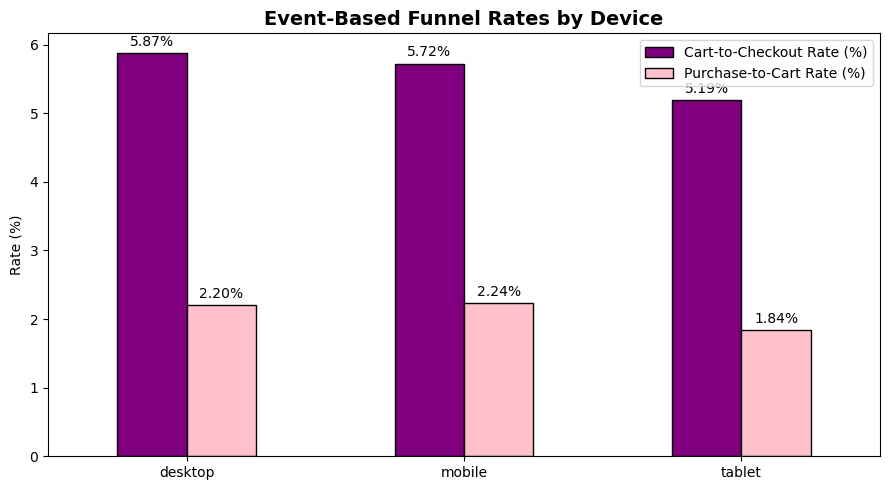

In [44]:
device_chart_data = (
    device_summary
    .set_index("Device")[
        [
            "Cart-to-Checkout Rate (%)",
            "Purchase-to-Cart Rate (%)"
        ]
    ]
)

ax = device_chart_data.plot(
    kind="bar",
    figsize=(9, 5),
    color=["purple", "pink"],
    edgecolor="black")


ax.set_title(
    "Event-Based Funnel Rates by Device",
    fontsize=14,
    fontweight="bold")

ax.set_xlabel("")
ax.set_ylabel("Rate (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Device Insight

Mobile recorded the highest purchase-to-cart rate at **2.24%**, followed closely by desktop at **2.20%**. Tablet recorded the lowest rate at **1.84%**.

The differences are relatively small, so the results do not prove that any particular device has a serious usability problem.

## 3. Country Performance

 Which countries generated the most purchase events?



### Purchase Events by Country

In [13]:
country_summary = (
    events.loc[events["type"] == "purchase"]
          .groupby("country")
          .size()
          .rename("Purchase Events")
          .reset_index()
)

country_summary["Purchase Event Share (%)"] = (
    country_summary["Purchase Events"]
    / country_summary["Purchase Events"].sum()
    * 100
)

country_summary = country_summary.sort_values(
    "Purchase Events",
    ascending=False
).reset_index(drop=True)

top_countries = country_summary.head(10)

display(top_countries.round(2))

,country,Purchase Events,Purchase Event Share (%)
0,US,6506,44.23
1,IN,1343,9.13
2,CA,1308,8.89
3,GB,442,3.00
4,ES,347,2.36
5,FR,309,2.10
6,CN,248,1.69
7,DE,238,1.62
8,JP,220,1.50
9,TW,215,1.46


### Top 10 Countries by Purchase Events

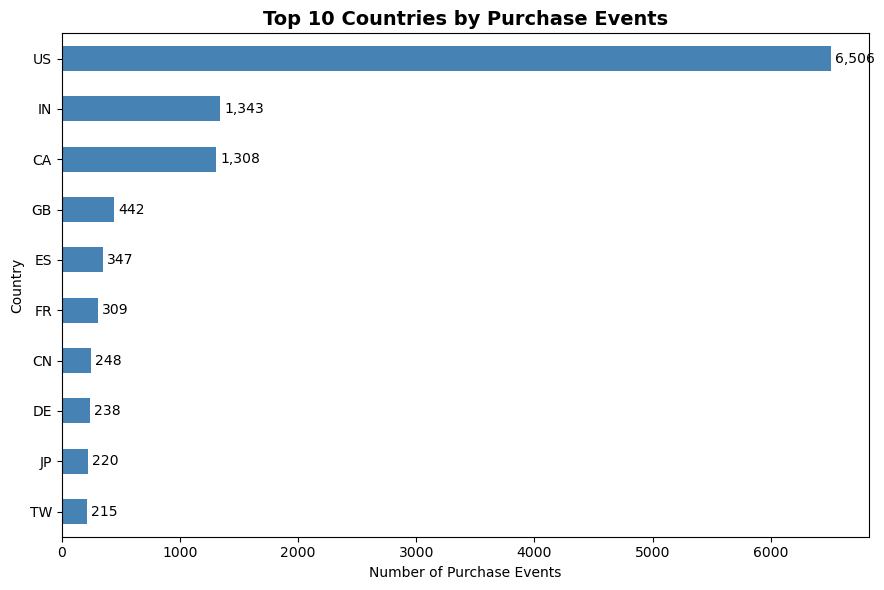

In [19]:
country_visual = top_countries.sort_values(
    "Purchase Events",
    ascending=True
)

ax = country_visual.plot(
    kind="barh",
    x="country",
    y="Purchase Events",
    figsize=(9, 6),
    color="steelblue",
    legend=False)

ax.set_title(
    "Top 10 Countries by Purchase Events",
    fontsize=14,
    fontweight="bold" )

ax.set_xlabel("Number of Purchase Events")
ax.set_ylabel("Country")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in country_visual["Purchase Events"]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()

### Country Insight

The United States generated **6,506 purchase events**, representing **44.23%** of all purchase events. India and Canada followed with **9.13%** and **8.89%**, respectively.

Together, these three countries contributed approximately **62.25%** of purchase events, showing that purchase activity was concentrated in a few markets.

## 4. Product Category Performance

Which product categories generated the most purchase events and revenue, and which recorded the strongest event-based conversion rates?



### Purchase Events by Category

In [21]:
item_lookup = (
    items[
        ["id", "category", "price_in_usd"]
    ]
    .rename(columns={"id": "item_id"})
)

product_events = events.merge(
    item_lookup,
    on="item_id",
    how="left",
    validate="many_to_one")

print("Events without a matched category:",
    product_events["category"].isna().sum())

Events without a matched category: 0


### Category Purchase Summary

In [23]:
category_purchase_summary = (
    product_events.loc[
        product_events["type"] == "purchase"
    ]
    .groupby("category")
    .size()
    .rename("Purchase Events")
    .reset_index())

category_purchase_summary["Purchase Event Share (%)"] = (
    category_purchase_summary["Purchase Events"]
    / category_purchase_summary["Purchase Events"].sum()
    * 100)

category_purchase_summary = (
    category_purchase_summary
    .sort_values("Purchase Events", ascending=False)
    .reset_index(drop=True))

top_purchase_categories = category_purchase_summary.head(10)

display(top_purchase_categories.round(2))

,category,Purchase Events,Purchase Event Share (%)
0,Apparel,4858,33.02
1,Campus Collection,1456,9.90
2,New,1397,9.50
3,Accessories,1173,7.97
4,Shop by Brand,818,5.56
5,Office,798,5.42
6,Drinkware,680,4.62
7,Bags,671,4.56
8,Clearance,633,4.30
9,Lifestyle,583,3.96


### Top Categories by Purchase Events

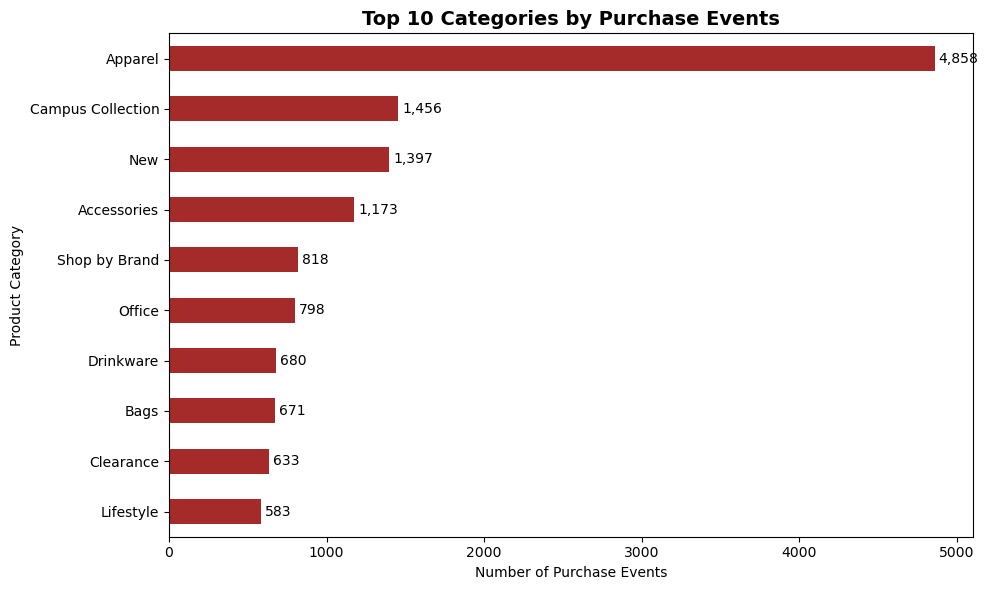

In [25]:
category_purchase_visual = (
    top_purchase_categories
    .sort_values("Purchase Events", ascending=True)
)

ax = category_purchase_visual.plot(
    kind="barh",
    x="category",
    y="Purchase Events",
    figsize=(10, 6),
    color="Brown",
    legend=False)

ax.set_title(
    "Top 10 Categories by Purchase Events",
    fontsize=14,
    fontweight="bold")

ax.set_xlabel("Number of Purchase Events")
ax.set_ylabel("Product Category")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in category_purchase_visual[
                "Purchase Events"
            ]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()

### Category Purchase Insight

Apparel generated **4,858 purchase events**, representing **33.02%** of all purchase events. Campus Collection and New followed with **9.90%** and **9.50%**.

Together, the top three categories accounted for approximately **52.42%** of purchase events. This shows that purchase activity was concentrated in a small number of categories.

### Revenue by Product Category

Revenue is calculated by summing `price_in_usd` across purchase-event rows. It represents recorded product value and does not include adjustments for discounts, taxes, returns or refunds.

In [26]:
category_revenue_summary = (
    product_events.loc[
        product_events["type"] == "purchase"
    ]
    .groupby("category")
    .agg(
        Purchase_Events=("type", "size"),
        Revenue_USD=("price_in_usd", "sum")
    )
    .reset_index()
)

category_revenue_summary["Revenue Share (%)"] = (
    category_revenue_summary["Revenue_USD"]
    / category_revenue_summary["Revenue_USD"].sum()
    * 100)

category_revenue_summary = (
    category_revenue_summary
    .sort_values("Revenue_USD", ascending=False)
    .reset_index(drop=True))

top_revenue_categories = category_revenue_summary.head(10)

print(
    "Total recorded product revenue:",
    f"${category_revenue_summary['Revenue_USD'].sum():,.2f}")

display(top_revenue_categories.round(2))

Total recorded product revenue: $289,407.00


,category,Purchase_Events,Revenue_USD,Revenue Share (%)
0,Apparel,4858,157235,54.33
1,Bags,671,19137,6.61
2,New,1397,18506,6.39
3,Campus Collection,1456,15553,5.37
4,Shop by Brand,818,15049,5.20
5,Accessories,1173,13810,4.77
6,Drinkware,680,10505,3.63
7,Uncategorized Items,477,10354,3.58
8,Lifestyle,583,10031,3.47
9,Clearance,633,8605,2.97


### Category Revenue Chart

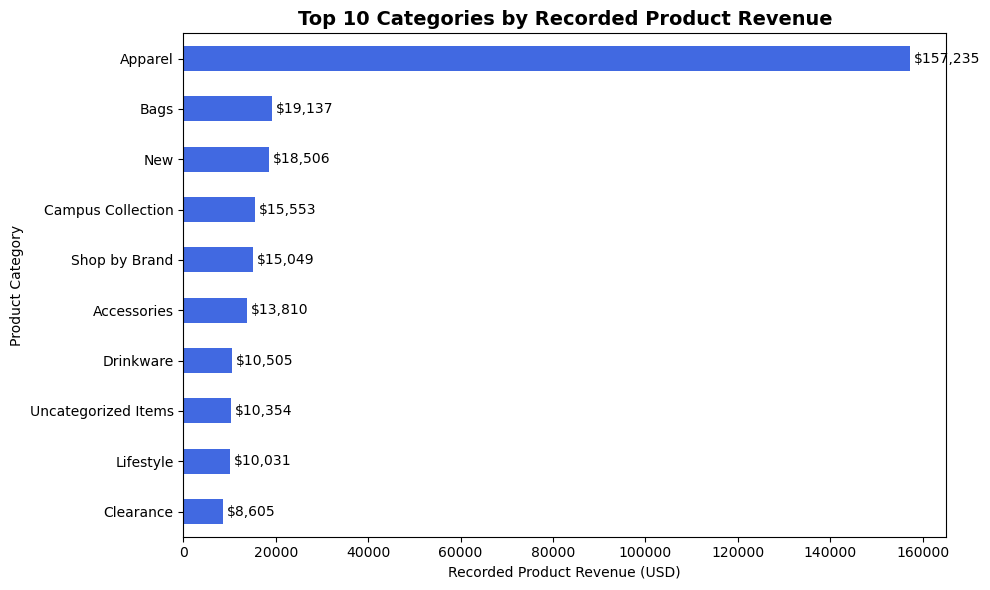

In [27]:
revenue_visual = (
    top_revenue_categories
    .sort_values("Revenue_USD", ascending=True)
)

ax = revenue_visual.plot(
    kind="barh",
    x="category",
    y="Revenue_USD",
    figsize=(10, 6),
    color="royalblue",
    legend=False)

ax.set_title(
    "Top 10 Categories by Recorded Product Revenue",
    fontsize=14,
    fontweight="bold") 

ax.set_xlabel("Recorded Product Revenue (USD)")
ax.set_ylabel("Product Category")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"${value:,.0f}"
            for value in revenue_visual["Revenue_USD"]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()

### Category Revenue Insight

Apparel generated **$157,235**, contributing **54.33%** of the total recorded product revenue. This was more than eight times the revenue generated by Bags, the second-highest category.

The results show a strong dependence on Apparel, which leads both purchase activity and recorded product revenue.

### Event-Based Purchase-to-Cart Rate by Category

This compares purchase-event volume with add-to-cart event volume within each product category.

In [31]:
category_funnel_summary = (
    product_events.groupby(["category", "type"])
                  .size()
                  .unstack(fill_value=0)
                  .reindex(columns=funnel_stages, fill_value=0))

category_funnel_summary = (
    category_funnel_summary[
        category_funnel_summary["add_to_cart"] > 0
    ]
    .copy())

category_funnel_summary["Purchase-to-Cart Rate (%)"] = (
    category_funnel_summary["purchase"]
    / category_funnel_summary["add_to_cart"]
    * 100)

category_conversion_summary = (
    category_funnel_summary
    .reset_index()
    .rename(columns={
        "add_to_cart": "Add-to-Cart Events",
        "begin_checkout": "Begin-Checkout Events",
        "purchase": "Purchase Events"
    })
    .sort_values(
        "Purchase-to-Cart Rate (%)",
        ascending=False
    )
    .reset_index(drop=True))



#### Minimum-Volume Rule

Categories with fewer than 100 add-to-cart events are excluded from the ranking because rates based on very small event counts can be misleading.

In [33]:
# Remove the extra "type" label above the columns

category_conversion_summary.columns.name = None

minimum_cart_events = 100

eligible_category_conversion = (
    category_conversion_summary[
        category_conversion_summary[
            "Add-to-Cart Events"
        ] >= minimum_cart_events
    ]
)

top_conversion_categories = (
    eligible_category_conversion
    .head(10)
    .reset_index(drop=True))

display(top_conversion_categories.round(2))

,category,Add-to-Cart Events,Begin-Checkout Events,Purchase Events,Purchase-to-Cart Rate (%)
0,Small Goods,3975,674,293,7.37
1,Gift Cards,189,52,13,6.88
2,Google,4206,576,214,5.09
3,Stationery,6149,681,292,4.75
4,Writing Instruments,5382,594,220,4.09
5,Campus Collection,40785,3483,1456,3.57
6,Fun,1017,60,36,3.54
7,Office,23343,2150,798,3.42
8,Drinkware,22068,1639,680,3.08
9,Eco-Friendly,425,57,13,3.06


### Categories with the Highest Purchase-to-Cart Rates

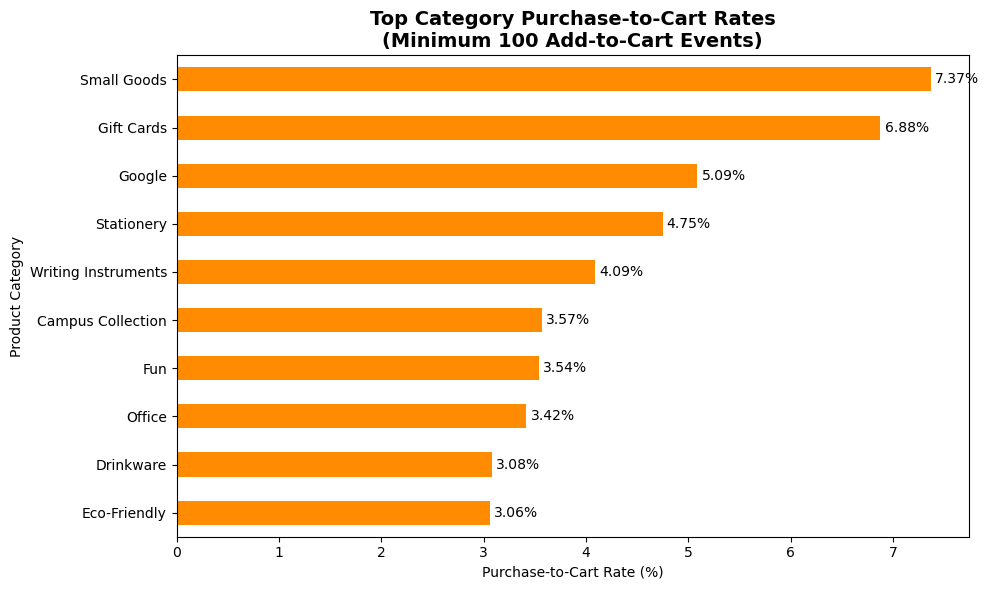

In [34]:
conversion_visual = (
    top_conversion_categories
    .sort_values(
        "Purchase-to-Cart Rate (%)",
        ascending=True
    )
)

ax = conversion_visual.plot(
    kind="barh",
    x="category",
    y="Purchase-to-Cart Rate (%)",
    figsize=(10, 6),
    color="darkorange",
    legend=False)

ax.set_title(
    "Top Category Purchase-to-Cart Rates\n"
    "(Minimum 100 Add-to-Cart Events)",
    fontsize=14,
    fontweight="bold")

ax.set_xlabel("Purchase-to-Cart Rate (%)")
ax.set_ylabel("Product Category")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3)

plt.tight_layout()
plt.show()

### Category Conversion Insight

Among categories with at least 100 add-to-cart events, Small Goods recorded the highest purchase-to-cart rate at **7.37%**, followed by Gift Cards at **6.88%** and Google at **5.09%**.

These categories converted relatively well but had much lower event volumes than Apparel. Their higher rates therefore do not automatically mean they generated more revenue.

## 5. Customer Value Analysis

 What does the user dataset show about recorded customer value?



In [35]:
ltv_validation = pd.Series({
    "Total users": len(users),
    "Unique user IDs": users["id"].nunique(),
    "Missing LTV values": users["ltv"].isna().sum(),
    "Negative LTV values": (users["ltv"] < 0).sum(),
    "Users with zero LTV": (users["ltv"] == 0).sum(),
    "Users with positive LTV": (users["ltv"] > 0).sum(),
    "Minimum LTV": users["ltv"].min(),
    "Median LTV": users["ltv"].median(),
    "Mean LTV": users["ltv"].mean(),
    "Maximum LTV": users["ltv"].max()
})

display(ltv_validation)

Total users                270154.000000
Unique user IDs            270154.000000
Missing LTV values              0.000000
Negative LTV values             0.000000
Users with zero LTV        265709.000000
Users with positive LTV      4445.000000
Minimum LTV                     0.000000
Median LTV                      0.000000
Mean LTV                        1.508865
Maximum LTV                  3360.000000
dtype: float64

### Zero and Positive LTV Users

Because most users have an LTV of zero, I compared zero and positive values separately. I did not create Low, Medium or High segments because the dataset does not provide those labels.

In [37]:
users["LTV_Status"] = users["ltv"].apply(
    lambda value: (
        "Positive LTV"
        if value > 0
        else "Zero LTV"
    )
)

ltv_status_summary = (
    users.groupby("LTV_Status")
         .agg(
             Users=("id", "nunique"),
             Total_LTV=("ltv", "sum"),
             Average_LTV=("ltv", "mean")
         )
         .reindex([
             "Zero LTV",
             "Positive LTV"
         ])
         .reset_index())

ltv_status_summary["User Share (%)"] = (
    ltv_status_summary["Users"]
    / ltv_status_summary["Users"].sum()
    * 100)

display(ltv_status_summary.round(2))

,LTV_Status,Users,Total_LTV,Average_LTV,User Share (%)
0,Zero LTV,265709,0,0.0,98.35
1,Positive LTV,4445,407626,91.7,1.65


### Positive LTV Summary

To examine the non-zero values separately, the summary below includes only users with positive LTV. All positive values, including the maximum value, remain included.

In [47]:
#positive LTV Summary:
positive_ltv = users.loc[
    users["ltv"] > 0,
    "ltv"
]

positive_ltv_summary = positive_ltv.describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
).round(2)

display(positive_ltv_summary)

count    4445.00
mean       91.70
std       124.43
min         1.00
25%        32.00
50%        57.00
75%       103.00
90%       188.00
95%       272.00
99%       573.36
max      3360.00
Name: ltv, dtype: float64

### Positive LTV Percentiles

The chart compares selected percentile values among users with positive LTV. The 99th percentile was 573.36, while the maximum value of 3,360 remains included in the summary table above.

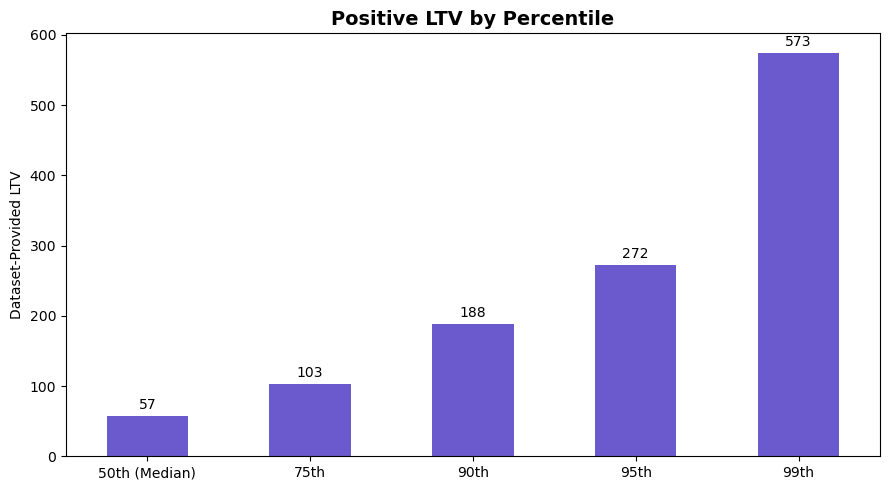

In [40]:
ltv_percentile_summary = pd.DataFrame({
    "Percentile": [
        "50th (Median)",
        "75th",
        "90th",
        "95th",
        "99th"
    ],
    "LTV": positive_ltv.quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]).values
})

ax = ltv_percentile_summary.plot(
    kind="bar",
    x="Percentile",
    y="LTV",
    figsize=(9, 5),
    color="slateblue",
    legend=False
)

ax.set_title(
    "Positive LTV by Percentile",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Dataset-Provided LTV")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()
plt.show()

### Customer Value Insight

Only **1.65%** of users had a positive LTV value. Among those users, the median was **57**, while 90% had an LTV of **188 or less**. A small number of much higher values increased the average to **91.70**.

These values come directly from `users.csv`; the notebook does not calculate or predict LTV.

## 6. What the Analysis Showed

A few things stood out from the analysis:

- Begin-checkout events were only **5.80%** of add-to-cart events, making the stage before checkout the main area to investigate.
- Device rates were fairly close. Mobile recorded the highest purchase-to-cart rate at **2.24%**, while tablet was lowest at **1.84%**.
- The United States accounted for **44.23%** of all purchase events.
- Apparel generated **33.02%** of purchase events and **54.33%** of recorded product revenue.
- Small Goods had the highest purchase-to-cart rate among categories with enough event volume, but it generated far fewer events than Apparel.
- Only **1.65%** of users had a positive LTV value in `users.csv`.

## Limitations

- Funnel rates compare event totals; they do not follow individual users through each stage.
- Revenue is based on product prices attached to purchase events and does not include discounts, taxes, returns or refunds.
- The LTV values were already provided in `users.csv`; this notebook does not calculate or predict customer lifetime value.
- The findings describe the available data and do not prove why users left the funnel.